# makemore Part 2 exercise

Improve the lecture MLP from dev NLL `2.1701` to `1.9412` by removing context, representation, and capacity bottlenecks—then regularizing the larger model.

In [1]:
import copy
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

%matplotlib inline
torch.set_float32_matmul_precision('high')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

device: cuda
GPU: NVIDIA GeForce RTX 5090 Laptop GPU


### Data

`.` marks padding/start and end-of-name. A name of length `L` yields `L + 1` next-character examples.

Unlike a `V^T` count table, embeddings and an MLP share statistical strength across contexts.

In [2]:
data_path = Path('names.txt')
assert data_path.exists(), f'Could not find {data_path.resolve()}'
words = data_path.read_text().splitlines()

chars = sorted(set(''.join(words)))
stoi = {ch: i + 1 for i, ch in enumerate(chars)}
stoi['.'] = 0
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(stoi)

print('number of names:', len(words))
print('number of unique names:', len(set(words)))
print('shortest / longest name:', min(map(len, words)), '/', max(map(len, words)))
print('vocabulary:', ''.join(itos[i] for i in range(vocab_size)))
print('vocab_size:', vocab_size)

number of names: 32033
number of unique names: 29494
shortest / longest name: 2 / 15
vocabulary: .abcdefghijklmnopqrstuvwxyz
vocab_size: 27


### Splits and context

- Split complete names 80/10/10 before building examples.
- Train fits parameters; dev selects the recipe; test is opened once.
- Use `block_size = 5`: contexts 6 and 8 lowered train loss without improving dev loss.

In [3]:
block_size = 5

def build_dataset(word_list):
    X, Y = [], []
    for word in word_list:
        context = [0] * block_size
        for ch in word + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

split_rng = random.Random(42)
split_rng.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

print('train:', Xtr.shape, Ytr.shape)
print('dev:  ', Xdev.shape, Ydev.shape)
print('test: ', Xte.shape, Yte.shape)

train: torch.Size([182625, 5]) torch.Size([182625])
dev:   torch.Size([22655, 5]) torch.Size([22655])
test:  torch.Size([22866, 5]) torch.Size([22866])


In [4]:
for x, y in zip(Xtr[:12], Ytr[:12]):
    context = ''.join(itos[i] for i in x.tolist())
    print(f'{context} ---> {itos[y.item()]}')

..... ---> y
....y ---> u
...yu ---> h
..yuh ---> e
.yuhe ---> n
yuhen ---> g
uheng ---> .
..... ---> d
....d ---> i
...di ---> o
..dio ---> n
.dion ---> d


### Final MLP

| setting | lecture | final |
|---|---:|---:|
| context | 3 | **5** |
| embedding | 10 | **24** |
| hidden width | 200 | **1536** |
| dropout | 0% | **15%** |

Shape contract: `(N,5) → (N,5,24) → (N,120) → (N,1536) → (N,27)`.

`C[index]` is an efficient row lookup equivalent to `one_hot(index) @ C`; `flatten(1)` preserves the batch axis and joins context features.

#### Capacity and regularization

High, similar train/dev loss indicated underfitting, so the model gained context, embedding capacity, and width. The resulting train/dev gap indicated overfitting; 15% dropout made the extra capacity generalize better.

In [5]:
n_embd = 24
n_hidden = 1536
dropout_p = 0.15
output_init_std = 0.001

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        fan_in = block_size * n_embd
        self.C = nn.Embedding(vocab_size, n_embd)
        self.fc1 = nn.Linear(fan_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, vocab_size)

        # Healthy tanh activations and almost-uniform initial predictions.
        nn.init.normal_(self.C.weight, mean=0.0, std=1.0)
        nn.init.normal_(
            self.fc1.weight,
            mean=0.0,
            std=(5.0 / 3.0) / math.sqrt(fan_in),
        )
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=output_init_std)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, idx):
        emb = self.C(idx)                         # (B, 5, 24)
        x = emb.flatten(1)                       # (B, 120)
        h = torch.tanh(self.fc1(x))              # (B, 1536)
        h = F.dropout(h, p=dropout_p, training=self.training)
        logits = self.fc2(h)                     # (B, 27)
        return logits

#### Initialization

Uniform 27-way predictions begin near `log(27) = 3.29584`. Tiny output weights avoid confident random logits, while tanh gain `(5/3)/√fan_in` keeps hidden activations useful for learning.

Reference: [PyTorch initialization documentation](https://docs.pytorch.org/docs/2.13/nn.init.html).

In [6]:
seed = 2147483647
torch.manual_seed(seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(seed)

model = MLP().to(device)
n_parameters = sum(p.numel() for p in model.parameters())
print(model)
print('number of parameters:', f'{n_parameters:,}')

MLP(
  (C): Embedding(27, 24)
  (fc1): Linear(in_features=120, out_features=1536, bias=True)
  (fc2): Linear(in_features=1536, out_features=27, bias=True)
)
number of parameters: 228,003


In [7]:
@torch.inference_mode()
def evaluate(model, X, Y, batch_size=16384):
    # model.eval() disables dropout.
    model.eval()
    total_nll = 0.0
    for start in range(0, len(X), batch_size):
        xb = X[start:start + batch_size].to(device)
        yb = Y[start:start + batch_size].to(device)
        logits = model(xb)
        total_nll += F.cross_entropy(logits, yb, reduction='sum').item()
    model.train()
    return total_nll / len(X)

initial_dev_loss = evaluate(model, Xdev, Ydev)
print('uniform loss:   ', math.log(vocab_size))
print('initial dev loss:', initial_dev_loss)

uniform loss:    3.295836866004329
initial dev loss: 3.296145908050099


### Optimization

- Loss: cross-entropy on raw logits.
- Batch: 1024.
- Optimizer: AdamW, `betas=(0.9,0.99)`, matrix/embedding weight decay `0.08`.
- Schedule: 100-step warmup to `3e-3`, cosine decay to `9e-5` at step 7500, then hold to step 10000.
- Evaluate dev every 500 steps and retain the best checkpoint.

The learning rate and decay were selected on dev across multiple seeds; test remained sealed. Clear gradients before every batch because `backward()` accumulates them.

In [8]:
batch_size = 1024
max_steps = 10000
cosine_end_step = 7500
eval_every = 500
peak_lr = 3e-3
warmup_steps = 100
floor_ratio = 0.03
weight_decay = 0.08

decay, no_decay = [], []
for parameter in model.parameters():
    (decay if parameter.ndim >= 2 else no_decay).append(parameter)

optimizer = torch.optim.AdamW(
    [
        {'params': decay, 'weight_decay': weight_decay},
        {'params': no_decay, 'weight_decay': 0.0},
    ],
    lr=peak_lr,
    betas=(0.9, 0.99),
    fused=(device.type == 'cuda'),
)

def learning_rate_at(step):
    if step < warmup_steps:
        return peak_lr * (step + 1) / warmup_steps
    if step >= cosine_end_step:
        return peak_lr * floor_ratio
    ratio = (step - warmup_steps) / (cosine_end_step - warmup_steps - 1)
    cosine = 0.5 * (1.0 + math.cos(math.pi * ratio))
    return peak_lr * (floor_ratio + (1.0 - floor_ratio) * cosine)

print('first / peak / cosine-end / final learning rate:')
print(
    learning_rate_at(0),
    learning_rate_at(warmup_steps - 1),
    learning_rate_at(cosine_end_step - 1),
    learning_rate_at(max_steps - 1),
)

first / peak / cosine-end / final learning rate:
3e-05 0.003 8.999999999999999e-05 8.999999999999999e-05


In [9]:
best_dev_loss = float('inf')
best_step = -1
best_state = None
lossi = []
lri = []
started = time.time()
batch_generator = torch.Generator().manual_seed(seed + 1)

model.train()
for step in range(max_steps):
    lr = learning_rate_at(step)
    for group in optimizer.param_groups:
        group['lr'] = lr

    ix = torch.randint(
        0, Xtr.shape[0], (batch_size,), generator=batch_generator
    )
    xb = Xtr[ix].to(device)
    yb = Ytr[ix].to(device)

    optimizer.zero_grad(set_to_none=True)
    logits = model(xb)
    loss = F.cross_entropy(logits, yb)

    loss.backward()
    optimizer.step()

    lossi.append(loss.item())
    lri.append(lr)

    should_evaluate = (step == 0 or (step + 1) % eval_every == 0 or step + 1 == max_steps)
    if should_evaluate:
        dev_loss = evaluate(model, Xdev, Ydev)
        if dev_loss < best_dev_loss:
            best_dev_loss = dev_loss
            best_step = step + 1
            best_state = copy.deepcopy(
                {name: tensor.detach().cpu() for name, tensor in model.state_dict().items()}
            )
        print(
            f'step {step + 1:4d}/{max_steps} | lr {lr:.6f} | '
            f'batch {loss.item():.4f} | dev {dev_loss:.6f} | '
            f'best {best_dev_loss:.6f} @ {best_step} | '
            f'{time.time() - started:.1f}s'
        )

step    1/10000 | lr 0.000030 | batch 3.2974 | dev 3.286147 | best 3.286147 @ 1 | 0.1s


step  500/10000 | lr 0.002979 | batch 2.0973 | dev 2.129293 | best 2.129293 @ 500 | 0.5s


step 1000/10000 | lr 0.002895 | batch 1.9723 | dev 2.096586 | best 2.096586 @ 1000 | 1.0s


step 1500/10000 | lr 0.002751 | batch 1.9946 | dev 2.079576 | best 2.079576 @ 1500 | 1.5s


step 2000/10000 | lr 0.002552 | batch 2.0559 | dev 2.059512 | best 2.059512 @ 2000 | 2.0s


...

step 8000/10000 | lr 0.000090 | batch 1.8047 | dev 1.941612 | best 1.941612 @ 8000 | 7.3s


step 8500/10000 | lr 0.000090 | batch 1.7650 | dev 1.941562 | best 1.941562 @ 8500 | 7.8s


step 9000/10000 | lr 0.000090 | batch 1.8544 | dev 1.941203 | best 1.941203 @ 9000 | 8.3s


step 9500/10000 | lr 0.000090 | batch 1.7963 | dev 1.942009 | best 1.941203 @ 9000 | 8.7s


step 10000/10000 | lr 0.000090 | batch 1.7975 | dev 1.941382 | best 1.941203 @ 9000 | 9.2s


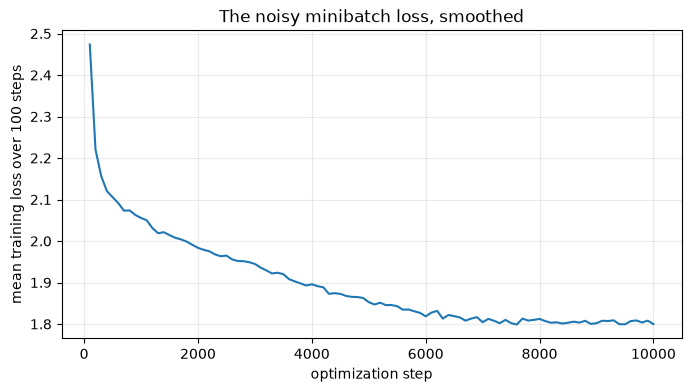

In [10]:
loss_tensor = torch.tensor(lossi)
window = 100
smoothed = loss_tensor.unfold(0, window, window).mean(1)
plt.figure(figsize=(8, 4))
plt.plot(torch.arange(len(smoothed)) * window + window, smoothed)
plt.xlabel('optimization step')
plt.ylabel(f'mean training loss over {window} steps')
plt.title('The noisy minibatch loss, smoothed')
plt.grid(alpha=0.25);

### Evaluation

Restore the dev-selected checkpoint, then evaluate test once. Metrics are character-level NLL including the end token.

In [11]:
assert best_state is not None
model.load_state_dict(best_state)

train_loss = evaluate(model, Xtr, Ytr)
dev_loss = evaluate(model, Xdev, Ydev)
test_loss = evaluate(model, Xte, Yte)  # the one final test evaluation

baseline_dev_loss = 2.1701
print(f'best step: {best_step}')
print(f'train loss: {train_loss:.6f}')
print(f'dev loss:   {dev_loss:.6f}   perplexity: {math.exp(dev_loss):.4f}')
print(f'test loss:  {test_loss:.6f}   perplexity: {math.exp(test_loss):.4f}')
print(f'dev NLL improvement over 2.1701: {baseline_dev_loss - dev_loss:.6f}')
print(
    'dev perplexity reduction:',
    f'{100 * (math.exp(baseline_dev_loss) - math.exp(dev_loss)) / math.exp(baseline_dev_loss):.2f}%'
)

best step: 9000
train loss: 1.722233
dev loss:   1.941203   perplexity: 6.9671
test loss:  1.940790   perplexity: 6.9643
dev NLL improvement over 2.1701: 0.228897
dev perplexity reduction: 20.46%


### Result

| split | NLL | perplexity |
|---|---:|---:|
| train | 1.7222 | 5.60 |
| dev | **1.9412** | **6.97** |
| test | **1.9408** | **6.96** |

Dev NLL improves by `0.2289`; the remaining train/dev gap shows that the 228K-parameter model still overfits.

### What did not help

- Contexts 6/8 and a second hidden layer reduced train loss, not dev loss.
- Extra width needed dropout; 15% worked better than 5% or 10% here.
- An input-to-output shortcut gave no stable dev gain.
- An n-gram mixture was excluded to keep this a single-MLP result.

Debugging rule: first verify that the model can overfit a tiny batch.

### Sampling

Generation reuses the training contract with batch size one: sample, shift the five-character context, and stop at `.`. `model.eval()` disables dropout; `inference_mode()` disables autograd.

In [12]:
@torch.inference_mode()
def sample_names(model, count=20, seed=2147483657):
    model.eval()
    generator = torch.Generator(device=device).manual_seed(seed)
    samples = []
    for _ in range(count):
        context = torch.zeros((1, block_size), dtype=torch.long, device=device)
        out = []
        for _ in range(30):  # safety cap for an unusually long sample
            logits = model(context)
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=generator).item()
            if ix == 0:
                break
            out.append(ix)
            context = torch.cat(
                [context[:, 1:], torch.tensor([[ix]], device=device)], dim=1
            )
        samples.append(''.join(itos[i] for i in out))
    return samples

print('\n'.join(sample_names(model)))

brently
ezri
delayna
jaylany
leylah
dejouurah
emilyn
grace
ewelliston
cantarello
kaissattan
tendell
kamdra
raan
jullana
doria
davel
thiab
zoriana
kaverick


### Review

- High and similar train/dev loss → remove information, representation, or capacity bottlenecks.
- Falling train loss with stalled dev loss → regularize instead of blindly scaling.
- Track shape semantics, train/dev behavior, optimizer state, and split usage.
- This 228K-parameter model is intentionally oversized for the task; its value is the diagnostic path, not inference efficiency.

Data caveat: 32,033 rows contain 29,494 unique names, so the official name-level random split can place duplicates across splits.

---

### Optional: SiLU

SiLU is unbounded on the positive side and changes activation statistics. This tuned comparison therefore uses 50% dropout; it is not an activation-only ablation.

In [13]:
silu_dropout_p = 0.50

class SiLUMLP(nn.Module):
    def __init__(self):
        super().__init__()
        fan_in = block_size * n_embd
        self.C = nn.Embedding(vocab_size, n_embd)
        self.fc1 = nn.Linear(fan_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, vocab_size)

        nn.init.normal_(self.C.weight, mean=0.0, std=1.0)
        # sqrt(2) / sqrt(fan_in) is a reasonable starting scale for SiLU.
        nn.init.normal_(
            self.fc1.weight, mean=0.0, std=math.sqrt(2.0) / math.sqrt(fan_in)
        )
        nn.init.zeros_(self.fc1.bias)
        nn.init.normal_(self.fc2.weight, mean=0.0, std=output_init_std)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, idx):
        emb = self.C(idx)
        x = emb.flatten(1)
        h = F.silu(self.fc1(x))
        h = F.dropout(h, p=silu_dropout_p, training=self.training)
        return self.fc2(h)

In [14]:
silu_seed = 2147483647
torch.manual_seed(silu_seed)
if device.type == 'cuda':
    torch.cuda.manual_seed_all(silu_seed)

silu_model = SiLUMLP().to(device)
silu_decay, silu_no_decay = [], []
for parameter in silu_model.parameters():
    (silu_decay if parameter.ndim >= 2 else silu_no_decay).append(parameter)

silu_optimizer = torch.optim.AdamW(
    [
        {'params': silu_decay, 'weight_decay': weight_decay},
        {'params': silu_no_decay, 'weight_decay': 0.0},
    ],
    lr=peak_lr,
    betas=(0.9, 0.99),
    fused=(device.type == 'cuda'),
)

# An independent generator makes the minibatch sequence reproducible.
silu_batch_generator = torch.Generator().manual_seed(silu_seed + 1)
print(silu_model)
print('number of parameters:', f'{sum(p.numel() for p in silu_model.parameters()):,}')
print('initial dev loss:', evaluate(silu_model, Xdev, Ydev))

SiLUMLP(
  (C): Embedding(27, 24)
  (fc1): Linear(in_features=120, out_features=1536, bias=True)
  (fc2): Linear(in_features=1536, out_features=27, bias=True)
)
number of parameters: 228,003
initial dev loss: 3.298406118958287


In [15]:
silu_best_dev_loss = float('inf')
silu_best_step = -1
silu_best_state = None
silu_started = time.time()

silu_model.train()
for step in range(max_steps):
    lr = learning_rate_at(step)
    for group in silu_optimizer.param_groups:
        group['lr'] = lr

    ix = torch.randint(
        0, Xtr.shape[0], (batch_size,), generator=silu_batch_generator
    )
    xb = Xtr[ix].to(device)
    yb = Ytr[ix].to(device)
    silu_optimizer.zero_grad(set_to_none=True)
    silu_loss = F.cross_entropy(silu_model(xb), yb)

    silu_loss.backward()
    silu_optimizer.step()

    should_evaluate = (
        step == 0 or (step + 1) % eval_every == 0 or step + 1 == max_steps
    )
    if should_evaluate:
        silu_current_dev = evaluate(silu_model, Xdev, Ydev)
        if silu_current_dev < silu_best_dev_loss:
            silu_best_dev_loss = silu_current_dev
            silu_best_step = step + 1
            silu_best_state = copy.deepcopy(
                {k: v.detach().cpu() for k, v in silu_model.state_dict().items()}
            )
        print(
            f'step {step + 1:4d}/{max_steps} | batch {silu_loss.item():.4f} | '
            f'dev {silu_current_dev:.6f} | best {silu_best_dev_loss:.6f} | '
            f'{time.time() - silu_started:.1f}s'
        )

silu_model.load_state_dict(silu_best_state)
silu_train_loss = evaluate(silu_model, Xtr, Ytr)
silu_dev_loss = evaluate(silu_model, Xdev, Ydev)
print('---')
print(f'tanh dev loss: {dev_loss:.6f}')
print(f'SiLU train loss: {silu_train_loss:.6f}')
print(f'SiLU dev loss:   {silu_dev_loss:.6f}')
print(f'SiLU - tanh:     {silu_dev_loss - dev_loss:+.6f}')

step    1/10000 | batch 3.3010 | dev 3.285208 | best 3.285208 | 0.0s


step  500/10000 | batch 2.0998 | dev 2.084595 | best 2.084595 | 2.4s


step 1000/10000 | batch 1.9965 | dev 2.054241 | best 2.054241 | 2.9s


step 1500/10000 | batch 2.0004 | dev 2.029520 | best 2.029520 | 3.3s


step 2000/10000 | batch 2.0303 | dev 2.015252 | best 2.015252 | 3.8s


...

step 8000/10000 | batch 1.8595 | dev 1.946237 | best 1.946237 | 9.2s


step 8500/10000 | batch 1.8021 | dev 1.946383 | best 1.946237 | 9.7s


step 9000/10000 | batch 1.8904 | dev 1.945342 | best 1.945342 | 10.1s


step 9500/10000 | batch 1.8753 | dev 1.945913 | best 1.945342 | 10.6s


step 10000/10000 | batch 1.8163 | dev 1.945242 | best 1.945242 | 11.0s
---
tanh dev loss: 1.941203
SiLU train loss: 1.760750
SiLU dev loss:   1.945242
SiLU - tanh:     +0.004039


#### SiLU result

SiLU with 50% dropout reaches dev NLL `1.9452`, slightly worse than tanh with 15% dropout at `1.9412`. A newer activation is not automatically better, especially when initialization already keeps tanh healthy.